# Step 5b — Refinement: stabilize NOE, scale up LSTM

Two targeted experiments on top of Step 5:

**A) NOE-v2** — same `NARX_MLP` architecture, but:
- **No warm-start**: random initialization instead of NARX weights → avoids landing in a "good-for-prediction-but-fragile" point.
- **`lr=1e-4`** (was `5e-4`): NOE training is BPTT through up to T=100 steps; lower LR helps.
- **More iterations** (3000) to compensate for the slower convergence from scratch.
- Fixed `T=50` (the sweet spot from Step 5).

**B) LSTM-v2** — same training recipe as Step 5, but **`hidden=64`** (was 32) and `T=50`.

At the end: re-compare against Step 5 winner (LSTM hidden=32, T=50, val SIM = 0.0587) and re-generate submission files if improved.


In [1]:
import time, math, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

REPO_DIR = Path(
    "/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/gym-unbalanced-disk-master/disc-benchmark-files"
)
WORK_DIR = Path(
    "/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment"
)
ARTIFACTS = WORK_DIR / 'artifacts'
SUBMISSIONS = WORK_DIR / 'submissions'

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(1); np.random.seed(1)
print('device:', device)

device: mps


## Helpers and data (same as Step 5)

In [2]:
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def rmse_from_sincos(s_pred, c_pred, s_true, c_true):
    th_p = np.arctan2(s_pred, c_pred)
    th_t = np.arctan2(s_true, c_true)
    return float(np.sqrt(np.mean(wrap_pi(th_p - th_t) ** 2)))

P = np.load(ARTIFACTS / 'step2_processed.npz')
u_tr_n, u_va_n = P['u_tr_n'], P['u_va_n']
sin_tr, cos_tr = P['sin_tr'], P['cos_tr']
sin_va, cos_va = P['sin_va'], P['cos_va']
th_tr,  th_va  = P['th_tr'],  P['th_va']
U_SCALE = float(P['U_SCALE'])

u_tr_t   = torch.from_numpy(u_tr_n.astype(np.float32)).to(device)
sin_tr_t = torch.from_numpy(sin_tr.astype(np.float32)).to(device)
cos_tr_t = torch.from_numpy(cos_tr.astype(np.float32)).to(device)
u_va_t   = torch.from_numpy(u_va_n.astype(np.float32)).to(device)
sin_va_t = torch.from_numpy(sin_va.astype(np.float32)).to(device)
cos_va_t = torch.from_numpy(cos_va.astype(np.float32)).to(device)

# NARX winner metadata (na, nb, hidden, in_dim).
ckpt_narx = torch.load(ARTIFACTS / 'best_narx.pt', map_location=device, weights_only=True)
NA = int(ckpt_narx['na']); NB = int(ckpt_narx['nb'])
HIDDEN_NARX = int(ckpt_narx['hidden']); IN_DIM = int(ckpt_narx['in_dim'])
print(f'NARX shape: na={NA}, nb={NB}, in_dim={IN_DIM}, hidden={HIDDEN_NARX}')


NARX shape: na=4, nb=6, in_dim=14, hidden=64


## A) NOE-v2: random init, lr=1e-4

In [3]:
class NARX_MLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

def unroll_narx_sim(model, u_init, sin_init, cos_init, u_future, na, nb):
    B, T = u_future.shape
    u_buf = u_init.clone(); s_buf = sin_init.clone(); c_buf = cos_init.clone()
    preds_s, preds_c = [], []
    for t in range(T):
        sc = torch.empty(B, 2 * na, device=u_buf.device, dtype=u_buf.dtype)
        sc[:, 0::2] = s_buf; sc[:, 1::2] = c_buf
        phi = torch.cat([u_buf, sc], dim=1)
        y = model(phi); s_hat, c_hat = y[:, 0], y[:, 1]
        preds_s.append(s_hat); preds_c.append(c_hat)
        u_buf = torch.cat([u_buf[:, 1:], u_future[:, t:t+1]], dim=1)
        s_buf = torch.cat([s_buf[:, 1:], s_hat.unsqueeze(1)], dim=1)
        c_buf = torch.cat([c_buf[:, 1:], c_hat.unsqueeze(1)], dim=1)
    return torch.stack(preds_s, dim=1), torch.stack(preds_c, dim=1)

def sample_noe_batch(B, T, na, nb):
    n0 = max(na, nb); Ntr = u_tr_t.shape[0]
    k0 = torch.randint(low=n0, high=Ntr - T + 1, size=(B,), device=device)
    ar_u = torch.arange(-nb, 0, device=device)
    ar_s = torch.arange(-na, 0, device=device)
    ar_T = torch.arange(T, device=device)
    return (u_tr_t[k0[:, None] + ar_u],
            sin_tr_t[k0[:, None] + ar_s],
            cos_tr_t[k0[:, None] + ar_s],
            u_tr_t[k0[:, None] + ar_T],
            sin_tr_t[k0[:, None] + ar_T],
            cos_tr_t[k0[:, None] + ar_T])

@torch.no_grad()
def eval_val_sim_narx(model, na, nb):
    model.eval()
    skip = max(na, nb)
    u_init = u_va_t[skip-nb:skip].unsqueeze(0)
    s_init = sin_va_t[skip-na:skip].unsqueeze(0)
    c_init = cos_va_t[skip-na:skip].unsqueeze(0)
    u_future = u_va_t[skip:].unsqueeze(0)
    ps, pc = unroll_narx_sim(model, u_init, s_init, c_init, u_future, na, nb)
    ps = ps.squeeze(0).cpu().numpy(); pc = pc.squeeze(0).cpu().numpy()
    return rmse_from_sincos(ps, pc, sin_va[skip:], cos_va[skip:])

@torch.no_grad()
def eval_val_pred_narx(model, na, nb):
    model.eval()
    n0 = max(na, nb); M = len(u_va_n) - n0
    ar_u = np.arange(-nb, 0); ar_th = np.arange(-na, 0)
    idx_u  = np.arange(n0, n0 + M)[:, None] + ar_u
    idx_th = np.arange(n0, n0 + M)[:, None] + ar_th
    Xu = u_va_n[idx_u]; Xs = sin_va[idx_th]; Xc = cos_va[idx_th]
    sc = np.empty((M, 2*na), dtype=np.float32)
    sc[:, 0::2] = Xs; sc[:, 1::2] = Xc
    X = np.concatenate([Xu, sc], axis=1).astype(np.float32)
    Y = model(torch.from_numpy(X).to(device)).cpu().numpy()
    return rmse_from_sincos(Y[:, 0], Y[:, 1], sin_va[n0:], cos_va[n0:])


In [4]:
def train_noe_v2(T_horizon=50, max_iters=3000, B=64, lr=1e-4, wd=1e-4,
                 lambda_uc=1e-2, eval_every=100, patience=12, verbose=True):
    model = NARX_MLP(IN_DIM, hidden=HIDDEN_NARX).to(device)  # random init (no warm-start)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=1/3, patience=6)

    best_sim = float('inf'); best_state = copy.deepcopy(model.state_dict()); bad = 0
    history = {'iter': [], 'train_loss': [], 'val_sim': []}
    t0 = time.time()
    for it in range(1, max_iters + 1):
        model.train()
        u_i, s_i, c_i, u_f, s_t, c_t = sample_noe_batch(B, T_horizon, NA, NB)
        ps, pc = unroll_narx_sim(model, u_i, s_i, c_i, u_f, NA, NB)
        mse = ((ps - s_t) ** 2 + (pc - c_t) ** 2).mean()
        uc  = ((ps ** 2 + pc ** 2 - 1.0) ** 2).mean()
        loss = mse + lambda_uc * uc
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if it % eval_every == 0:
            v = eval_val_sim_narx(model, NA, NB)
            sched.step(v)
            history['iter'].append(it); history['train_loss'].append(float(loss.item())); history['val_sim'].append(v)
            improved = v < best_sim - 1e-6
            if improved:
                best_sim = v; best_state = copy.deepcopy(model.state_dict()); bad = 0
            else:
                bad += 1
            if verbose:
                print(f'  it={it:>4}  loss={loss.item():.4e}  val_sim={v:.4f}  best={best_sim:.4f}  bad={bad}')
            if bad >= patience:
                if verbose: print(f'  early stop at iter {it}');
                break
    model.load_state_dict(best_state)
    return {
        'name': 'NOE-MLP v2 (rand init, lr=1e-4, T=50)',
        'family': 'NOE',
        'state_dict': best_state,
        'val_pred': eval_val_pred_narx(model, NA, NB),
        'val_sim':  eval_val_sim_narx(model, NA, NB),
        'history':  history,
        'time_s':   time.time() - t0,
    }

print('Training NOE-v2 (random init, lr=1e-4, T=50)...')
res_noe_v2 = train_noe_v2()
print(f'\nDone. val PRED = {res_noe_v2["val_pred"]:.4f}   val SIM = {res_noe_v2["val_sim"]:.4f} rad   [{res_noe_v2["time_s"]:.1f}s]')


Training NOE-v2 (random init, lr=1e-4, T=50)...
  it= 100  loss=2.0944e-01  val_sim=0.4912  best=0.4912  bad=0
  it= 200  loss=1.4130e-01  val_sim=0.4072  best=0.4072  bad=0
  it= 300  loss=1.2666e-01  val_sim=0.3949  best=0.3949  bad=0
  it= 400  loss=9.8010e-02  val_sim=0.3867  best=0.3867  bad=0
  it= 500  loss=9.8094e-02  val_sim=0.3630  best=0.3630  bad=0
  it= 600  loss=6.6315e-02  val_sim=0.2846  best=0.2846  bad=0
  it= 700  loss=4.5119e-02  val_sim=0.2735  best=0.2735  bad=0
  it= 800  loss=3.9663e-02  val_sim=0.2705  best=0.2705  bad=0
  it= 900  loss=3.3118e-02  val_sim=0.2620  best=0.2620  bad=0
  it=1000  loss=2.9013e-02  val_sim=0.2562  best=0.2562  bad=0
  it=1100  loss=1.9967e-02  val_sim=0.2595  best=0.2562  bad=1
  it=1200  loss=3.1027e-02  val_sim=0.2438  best=0.2438  bad=0
  it=1300  loss=3.2712e-02  val_sim=0.2470  best=0.2438  bad=1
  it=1400  loss=1.8653e-02  val_sim=0.2308  best=0.2308  bad=0
  it=1500  loss=2.2438e-02  val_sim=0.2283  best=0.2283  bad=0
  it=16

## B) LSTM-v2: hidden=64

In [5]:
class LSTMNarx(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.hidden = hidden
        self.cell = nn.LSTMCell(input_size=3, hidden_size=hidden)
        self.head = nn.Linear(hidden, 2)
    def init_state(self, B, device):
        return (torch.zeros(B, self.hidden, device=device),
                torch.zeros(B, self.hidden, device=device))

N_INIT = 10

def unroll_lstm_window(model, u_win, sin_win, cos_win, n_init, T):
    B = u_win.shape[0]
    h, c = model.init_state(B, u_win.device)
    for t in range(n_init):
        x = torch.stack([u_win[:, t], sin_win[:, t], cos_win[:, t]], dim=-1)
        h, c = model.cell(x, (h, c))
    last_pred = model.head(h)
    scored = [last_pred]
    for t in range(n_init, n_init + T - 1):
        x = torch.stack([u_win[:, t], last_pred[:, 0], last_pred[:, 1]], dim=-1)
        h, c = model.cell(x, (h, c))
        last_pred = model.head(h)
        scored.append(last_pred)
    pred = torch.stack(scored, dim=1)
    return pred[..., 0], pred[..., 1]

def sample_lstm_batch(B, T):
    L = N_INIT + T; Ntr = u_tr_t.shape[0]
    k0 = torch.randint(low=0, high=Ntr - L + 1, size=(B,), device=device)
    ar = torch.arange(L, device=device); idx = k0[:, None] + ar
    return u_tr_t[idx], sin_tr_t[idx], cos_tr_t[idx]

@torch.no_grad()
def eval_val_sim_lstm(model):
    model.eval()
    Nv = u_va_t.shape[0]; T_eff = Nv - N_INIT
    ps, pc = unroll_lstm_window(model, u_va_t.unsqueeze(0), sin_va_t.unsqueeze(0),
                                 cos_va_t.unsqueeze(0), N_INIT, T_eff)
    ps = ps.squeeze(0).cpu().numpy(); pc = pc.squeeze(0).cpu().numpy()
    return rmse_from_sincos(ps, pc, sin_va[N_INIT:], cos_va[N_INIT:])

@torch.no_grad()
def eval_val_pred_lstm(model):
    model.eval()
    Nv = u_va_t.shape[0]
    h, c = model.init_state(1, device)
    preds_s, preds_c = [], []
    for t in range(Nv - 1):
        x = torch.stack([u_va_t[t:t+1], sin_va_t[t:t+1], cos_va_t[t:t+1]], dim=-1)
        h, c = model.cell(x, (h, c)); y = model.head(h)
        preds_s.append(y[0, 0].item()); preds_c.append(y[0, 1].item())
    ps = np.array(preds_s); pc = np.array(preds_c)
    return rmse_from_sincos(ps[N_INIT-1:], pc[N_INIT-1:], sin_va[N_INIT:], cos_va[N_INIT:])


In [6]:
def train_lstm_v2(hidden=64, T_horizon=50, max_iters=3000, B=64, lr=1e-3, wd=1e-4,
                  lambda_uc=1e-2, eval_every=100, patience=10, verbose=True):
    model = LSTMNarx(hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=1/3, patience=5)

    best_sim = float('inf'); best_state = copy.deepcopy(model.state_dict()); bad = 0
    history = {'iter': [], 'train_loss': [], 'val_sim': []}
    t0 = time.time()
    for it in range(1, max_iters + 1):
        model.train()
        u_w, s_w, c_w = sample_lstm_batch(B, T_horizon)
        ps, pc = unroll_lstm_window(model, u_w, s_w, c_w, N_INIT, T_horizon)
        s_t = s_w[:, N_INIT:N_INIT + T_horizon]; c_t = c_w[:, N_INIT:N_INIT + T_horizon]
        mse = ((ps - s_t) ** 2 + (pc - c_t) ** 2).mean()
        uc  = ((ps ** 2 + pc ** 2 - 1.0) ** 2).mean()
        loss = mse + lambda_uc * uc
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if it % eval_every == 0:
            v = eval_val_sim_lstm(model)
            sched.step(v)
            history['iter'].append(it); history['train_loss'].append(float(loss.item())); history['val_sim'].append(v)
            improved = v < best_sim - 1e-6
            if improved:
                best_sim = v; best_state = copy.deepcopy(model.state_dict()); bad = 0
            else:
                bad += 1
            if verbose:
                print(f'  it={it:>4}  loss={loss.item():.4e}  val_sim={v:.4f}  best={best_sim:.4f}  bad={bad}')
            if bad >= patience:
                if verbose: print(f'  early stop at iter {it}')
                break
    model.load_state_dict(best_state)
    return {
        'name': f'LSTM v2 (hidden={hidden}, T={T_horizon})',
        'family': 'LSTM',
        'hidden': hidden,
        'state_dict': best_state,
        'val_pred': eval_val_pred_lstm(model),
        'val_sim':  eval_val_sim_lstm(model),
        'history':  history,
        'time_s':   time.time() - t0,
    }

print('\nTraining LSTM-v2 (hidden=64, T=50)...')
res_lstm_v2 = train_lstm_v2()
print(f'\nDone. val PRED = {res_lstm_v2["val_pred"]:.4f}   val SIM = {res_lstm_v2["val_sim"]:.4f} rad   [{res_lstm_v2["time_s"]:.1f}s]')



Training LSTM-v2 (hidden=64, T=50)...
  it= 100  loss=6.7227e-02  val_sim=0.2852  best=0.2852  bad=0
  it= 200  loss=1.3989e-02  val_sim=0.2470  best=0.2470  bad=0
  it= 300  loss=4.4009e-03  val_sim=0.1089  best=0.1089  bad=0
  it= 400  loss=2.1324e-03  val_sim=0.0976  best=0.0976  bad=0
  it= 500  loss=3.0934e-03  val_sim=0.1088  best=0.0976  bad=1
  it= 600  loss=2.2586e-03  val_sim=0.0857  best=0.0857  bad=0
  it= 700  loss=2.5014e-03  val_sim=0.1076  best=0.0857  bad=1
  it= 800  loss=1.7641e-03  val_sim=0.0794  best=0.0794  bad=0
  it= 900  loss=1.3897e-03  val_sim=0.0935  best=0.0794  bad=1
  it=1000  loss=1.2254e-03  val_sim=0.0831  best=0.0794  bad=2
  it=1100  loss=4.9622e-03  val_sim=0.0737  best=0.0737  bad=0
  it=1200  loss=1.8224e-03  val_sim=0.1162  best=0.0737  bad=1
  it=1300  loss=2.3319e-03  val_sim=0.1004  best=0.0737  bad=2
  it=1400  loss=1.9367e-03  val_sim=0.0744  best=0.0737  bad=3
  it=1500  loss=1.1932e-03  val_sim=0.1333  best=0.0737  bad=4
  it=1600  loss=

## Comparison with Step 5 winner

In [7]:
# Step 5 results (from previous run, no need to retrain).
PREV = [
    {'name': 'NARX-MLP (Step 3)',       'val_pred': 0.0050, 'val_sim': 0.1494},
    {'name': 'NOE-MLP T=50 (Step 5)',   'val_pred': 0.0056, 'val_sim': 0.0959},
    {'name': 'LSTM T=50 h=32 (Step 5)', 'val_pred': 0.0319, 'val_sim': 0.0587},
]
NEW = [
    {'name': res_noe_v2['name'],  'val_pred': res_noe_v2['val_pred'],  'val_sim': res_noe_v2['val_sim']},
    {'name': res_lstm_v2['name'], 'val_pred': res_lstm_v2['val_pred'], 'val_sim': res_lstm_v2['val_sim']},
]
all_rows = PREV + NEW

print(f'{"name":<40} {"val_PRED [rad]":>15} {"val_SIM [rad]":>14} {"val_SIM [deg]":>14}')
print('-' * 90)
for r in all_rows:
    print(f'{r["name"]:<40} {r["val_pred"]:>15.4f} {r["val_sim"]:>14.4f} {np.rad2deg(r["val_sim"]):>14.2f}')
print()
print('Repo baselines:')
print(f'{"Good NN sim":<40} {0.00382:>15.4f} {0.0271:>14.4f} {1.55:>14.2f}')
print(f'{"Lower bound sim":<40} {"-":>15} {0.0195:>14.4f} {1.12:>14.2f}')


name                                      val_PRED [rad]  val_SIM [rad]  val_SIM [deg]
------------------------------------------------------------------------------------------
NARX-MLP (Step 3)                                 0.0050         0.1494           8.56
NOE-MLP T=50 (Step 5)                             0.0056         0.0959           5.49
LSTM T=50 h=32 (Step 5)                           0.0319         0.0587           3.36
NOE-MLP v2 (rand init, lr=1e-4, T=50)             0.0777         0.1589           9.10
LSTM v2 (hidden=64, T=50)                         0.0243         0.0449           2.57

Repo baselines:
Good NN sim                                       0.0038         0.0271           1.55
Lower bound sim                                        -         0.0195           1.12


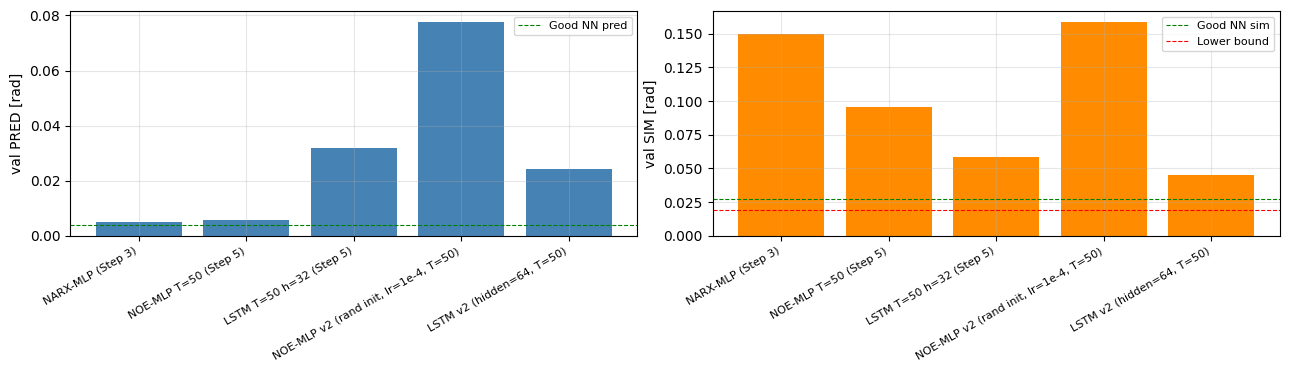

In [8]:
# Bar chart.
names = [r['name'] for r in all_rows]
sims  = [r['val_sim']  for r in all_rows]
preds = [r['val_pred'] for r in all_rows]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(range(len(names)), preds, color='steelblue')
ax[0].axhline(0.00382, color='green', ls='--', lw=0.8, label='Good NN pred')
ax[0].set_xticks(range(len(names))); ax[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax[0].set_ylabel('val PRED [rad]'); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)
ax[1].bar(range(len(names)), sims, color='darkorange')
ax[1].axhline(0.0271, color='green', ls='--', lw=0.8, label='Good NN sim')
ax[1].axhline(0.0195, color='red',   ls='--', lw=0.8, label='Lower bound')
ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax[1].set_ylabel('val SIM [rad]'); ax[1].grid(alpha=0.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## Pick the overall winner and (if improved) regenerate submission

In [9]:
STEP5_WINNER_SIM = 0.0587
candidates = [
    ('NOE v2',  res_noe_v2,  'NOE'),
    ('LSTM v2', res_lstm_v2, 'LSTM'),
]
best_label, best_res, best_family = min(candidates, key=lambda x: x[1]['val_sim'])
print(f'Best in Step 5b: {best_label} -> val_sim = {best_res["val_sim"]:.4f} rad ({np.rad2deg(best_res["val_sim"]):.2f}\u00b0)')
improved = best_res['val_sim'] < STEP5_WINNER_SIM
print(f'Improved over Step 5 LSTM h=32 (0.0587 rad)? {improved}')


Best in Step 5b: LSTM v2 -> val_sim = 0.0449 rad (2.57°)
Improved over Step 5 LSTM h=32 (0.0587 rad)? True


In [10]:
if improved:
    # Rebuild model from state_dict and regenerate submission files.
    if best_family == 'NOE':
        model = NARX_MLP(IN_DIM, hidden=HIDDEN_NARX).to(device)
    else:
        model = LSTMNarx(hidden=best_res['hidden']).to(device)
    model.load_state_dict(best_res['state_dict']); model.eval()

    save_dict = {
        'family': best_family,
        'state_dict': best_res['state_dict'],
        'val_pred': best_res['val_pred'],
        'val_sim':  best_res['val_sim'],
        'U_SCALE':  U_SCALE,
    }
    if best_family == 'NOE':
        save_dict.update({'na': NA, 'nb': NB, 'in_dim': IN_DIM, 'hidden': HIDDEN_NARX})
    else:
        save_dict.update({'n_init': N_INIT, 'lstm_hidden': best_res['hidden']})
    torch.save(save_dict, ARTIFACTS / 'best_advanced.pt')
    print('Saved', ARTIFACTS / 'best_advanced.pt')

    # PREDICTION submission.
    test_pred = np.load(REPO_DIR / 'hidden-test-prediction-submission-file.npz')
    upast  = test_pred['upast']; thpast = test_pred['thpast']
    Ntp = upast.shape[0]
    if best_family == 'NOE':
        u_win = (upast[:, -NB:] / U_SCALE).astype(np.float32)
        s_win = np.sin(thpast[:, -NA:]).astype(np.float32)
        c_win = np.cos(thpast[:, -NA:]).astype(np.float32)
        sc = np.empty((Ntp, 2 * NA), dtype=np.float32)
        sc[:, 0::2] = s_win; sc[:, 1::2] = c_win
        Phi = np.concatenate([u_win, sc], axis=1)
        with torch.no_grad():
            Y = model(torch.from_numpy(Phi).to(device)).cpu().numpy()
        th_pred_test = np.arctan2(Y[:, 0], Y[:, 1])
    else:
        u_n = (upast / U_SCALE).astype(np.float32)
        s_n = np.sin(thpast).astype(np.float32); c_n = np.cos(thpast).astype(np.float32)
        Up = torch.from_numpy(u_n).to(device)
        Sp = torch.from_numpy(s_n).to(device); Cp = torch.from_numpy(c_n).to(device)
        with torch.no_grad():
            h, c = model.init_state(Ntp, device)
            for t in range(upast.shape[1]):
                x = torch.stack([Up[:, t], Sp[:, t], Cp[:, t]], dim=-1)
                h, c = model.cell(x, (h, c))
            Y = model.head(h).cpu().numpy()
        th_pred_test = np.arctan2(Y[:, 0], Y[:, 1])
    tag = 'noe-v2' if best_family == 'NOE' else 'lstm-v2'
    out_pred = SUBMISSIONS / f'{tag}-prediction-submission-file.npz'
    np.savez(out_pred, upast=upast, thpast=thpast, thnow=th_pred_test)
    print('Saved', out_pred)

    # SIMULATION submission.
    test_sim = np.load(REPO_DIR / 'hidden-test-simulation-submission-file.npz')
    u_sim_raw = test_sim['u']; th_sim_seed = test_sim['th'].copy()
    u_sim_n = (u_sim_raw / U_SCALE).astype(np.float32)
    sin_seed = np.sin(th_sim_seed).astype(np.float32)
    cos_seed = np.cos(th_sim_seed).astype(np.float32)
    skip_sim = 50

    if best_family == 'NOE':
        u_t = torch.from_numpy(u_sim_n).to(device)
        s_t = torch.from_numpy(sin_seed).to(device); c_t = torch.from_numpy(cos_seed).to(device)
        with torch.no_grad():
            u_init   = u_t[skip_sim - NB:skip_sim].unsqueeze(0)
            s_init   = s_t[skip_sim - NA:skip_sim].unsqueeze(0)
            c_init   = c_t[skip_sim - NA:skip_sim].unsqueeze(0)
            u_future = u_t[skip_sim:].unsqueeze(0)
            ps, pc = unroll_narx_sim(model, u_init, s_init, c_init, u_future, NA, NB)
        th_after = np.arctan2(ps.squeeze(0).cpu().numpy(), pc.squeeze(0).cpu().numpy())
    else:
        Nsim = len(u_sim_n)
        Up = torch.from_numpy(u_sim_n).to(device).unsqueeze(0)
        Sp = torch.from_numpy(sin_seed).to(device).unsqueeze(0)
        Cp = torch.from_numpy(cos_seed).to(device).unsqueeze(0)
        with torch.no_grad():
            h, c = model.init_state(1, device)
            for t in range(skip_sim):
                x = torch.stack([Up[:, t], Sp[:, t], Cp[:, t]], dim=-1)
                h, c = model.cell(x, (h, c))
            last_pred = model.head(h)
            out_s = []; out_c = []
            for t in range(skip_sim, Nsim):
                x = torch.stack([Up[:, t], last_pred[:, 0], last_pred[:, 1]], dim=-1)
                h, c = model.cell(x, (h, c)); last_pred = model.head(h)
                out_s.append(last_pred[0, 0].item()); out_c.append(last_pred[0, 1].item())
        th_after = np.arctan2(np.array(out_s), np.array(out_c))
    th_sim_full = np.concatenate([th_sim_seed[:skip_sim], th_after])
    out_sim = SUBMISSIONS / f'{tag}-simulation-submission-file.npz'
    np.savez(out_sim, th=th_sim_full, u=u_sim_raw)
    print('Saved', out_sim)
else:
    print('No improvement over Step 5 winner. Keeping lstm-* submission files.')


Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/artifacts/best_advanced.pt
Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/submissions/lstm-v2-prediction-submission-file.npz
Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/submissions/lstm-v2-simulation-submission-file.npz


## Free-run plot of the best Step 5b model

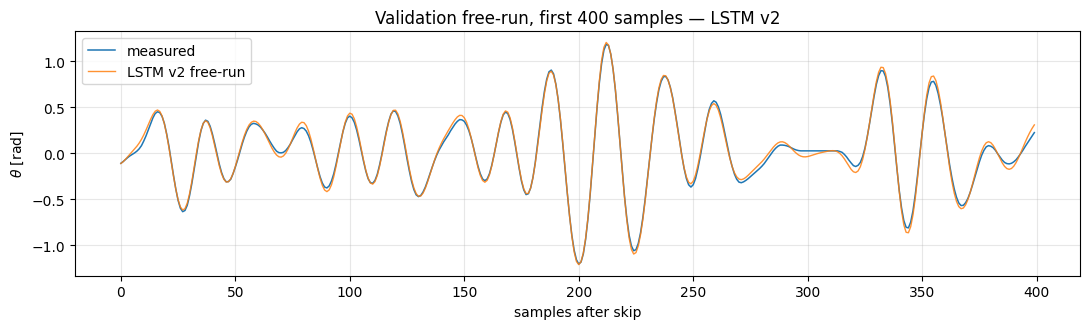

In [11]:
# Plot the best Step 5b model free-run on the first 400 val samples.
if best_family == 'NOE':
    model_plot = NARX_MLP(IN_DIM, hidden=HIDDEN_NARX).to(device)
    model_plot.load_state_dict(best_res['state_dict']); model_plot.eval()
    skip = max(NA, NB)
    with torch.no_grad():
        u_init = u_va_t[skip-NB:skip].unsqueeze(0)
        s_init = sin_va_t[skip-NA:skip].unsqueeze(0)
        c_init = cos_va_t[skip-NA:skip].unsqueeze(0)
        u_future = u_va_t[skip:].unsqueeze(0)
        ps, pc = unroll_narx_sim(model_plot, u_init, s_init, c_init, u_future, NA, NB)
    th_best = np.arctan2(ps.squeeze(0).cpu().numpy(), pc.squeeze(0).cpu().numpy())
    th_meas = th_va[skip:]
else:
    model_plot = LSTMNarx(hidden=best_res['hidden']).to(device)
    model_plot.load_state_dict(best_res['state_dict']); model_plot.eval()
    Nv = u_va_t.shape[0]
    with torch.no_grad():
        ps, pc = unroll_lstm_window(model_plot, u_va_t.unsqueeze(0), sin_va_t.unsqueeze(0),
                                     cos_va_t.unsqueeze(0), N_INIT, Nv - N_INIT)
    th_best = np.arctan2(ps.squeeze(0).cpu().numpy(), pc.squeeze(0).cpu().numpy())
    th_meas = th_va[N_INIT:]

n_show = 400
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(th_meas[:n_show], label='measured', lw=1.1)
ax.plot(th_best[:n_show], label=f'{best_label} free-run', lw=1.0, alpha=0.85)
ax.set_xlabel('samples after skip'); ax.set_ylabel(r'$\theta$ [rad]'); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f'Validation free-run, first {n_show} samples — {best_label}')
plt.tight_layout(); plt.show()


---
**End of Step 5b.**

If a Step 5b variant improved over Step 5, the new submission files have the `-v2-` suffix and the saved `best_advanced.pt` is updated.
